# GRA: GR-Adam + synthetic tests

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:

Particle zoo, from photons to massive hadrons

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Main

In [3]:
from optimizers import *
from test.test import *

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

class HeterogeneousRelAdam(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0.0, coupling=1.0, inertial_sourcing=True, bias_correction=True):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        coupling=coupling, inertial_sourcing=inertial_sourcing,
                        bias_correction=bias_correction)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr, eps = group["lr"], group["eps"]
            beta1, beta2 = group["betas"]
            # Global fallback
            global_coupling = group["coupling"]
            
            for p in group["params"]:
                if p.grad is None: continue
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                
                state["step"] += 1
                step = state["step"]
                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                grad = p.grad
                
                if group["weight_decay"] != 0:
                    p.data.mul_(1.0 - lr * group["weight_decay"])

                exp_avg.mul_(beta1).add_(grad, alpha=1.0 - beta1)
                
                # --- HETEROGENEOUS COUPLING LOGIC ---
                # Check if this specific parameter has a distinct 'mass' (coupling)
                if hasattr(p, 'coupling_map'):
                    # p.coupling_map is a Tensor of the same shape as p
                    C = p.coupling_map
                else:
                    C = global_coupling

                # Calculate Gamma (Handles both scalar C and Tensor C)
                # If C is scalar infinity, gamma is 1.0
                # If C is tensor, we calculate element-wise
                metric_psi = exp_avg_sq.sqrt().add(eps)
                p_scaled = exp_avg / metric_psi
                
                # We handle the "Infinite C" case carefully for tensors
                if isinstance(C, float) and C == float('inf'):
                    gamma = 1.0
                else:
                    # Relativistic Gamma = sqrt(1 + (p_scaled / C)^2)
                    gamma = (1.0 + (p_scaled / C).pow(2)).sqrt()
                
                # Metric Source Update
                source_proxy = exp_avg if group["inertial_sourcing"] else grad
                source_sq = source_proxy.pow(2)
                
                if isinstance(gamma, float) and gamma == 1.0:
                    source_term = source_sq
                else:
                    source_term = source_sq / gamma
                
                exp_avg_sq.mul_(beta2).add_(source_term, alpha=1.0 - beta2)
                
                # Step Update
                bc1 = 1.0 - beta1 ** step if group["bias_correction"] else 1.0
                bc2 = 1.0 - beta2 ** step if group["bias_correction"] else 1.0
                step_size = lr / bc1
                denom = (exp_avg_sq / bc2).sqrt()
                
                if not (isinstance(gamma, float) and gamma == 1.0):
                    denom.mul_(gamma)
                denom.add_(eps)
                
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import copy

# ==========================================
# 1. Setup (Data & Optimizer)
# ==========================================
def generate_data(
    n_samples=300,
    outlier_ratio=0.1,
    outlier_magnitude_min=2.0,
    outlier_magnitude_max=8.0, 
):
    # True function: y = sin(3x)
    x = torch.linspace(-3, 3, n_samples).unsqueeze(1)
    y = torch.sin(3 * x)

    # Add small background noise
    y = y + torch.randn_like(y) * 0.1

    # Add outliers
    n_outliers = int(n_samples * outlier_ratio)
    indices = torch.randperm(n_samples)[:n_outliers]

    # Random sign (+/- 1)
    sign = (torch.randint(0, 2, (n_outliers, 1), device=y.device).float() * 2 - 1)

    # Magnitude sampled uniformly in [min, max]
    mag = torch.empty((n_outliers, 1), device=y.device).uniform_(
        float(outlier_magnitude_min), float(outlier_magnitude_max)
    )

    y[indices] = y[indices] + sign * mag
    return x, y, indices

class HeterogeneousRelAdam(torch.optim.Optimizer):
    """
    RelativisticAdam with support for per-parameter 'coupling_map'.
    """
    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
        coupling=3.0,
        inertial_sourcing=True,
    ):
        coupling = self._normalize_coupling(coupling)
        if lr < 0.0: raise ValueError(f"Invalid learning rate: {lr}")
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay,
                        coupling=coupling, inertial_sourcing=inertial_sourcing)
        super().__init__(params, defaults)

    def _normalize_coupling(self, coupling):
        if coupling is None: return float("inf")
        if isinstance(coupling, str):
            if coupling.strip().lower() in {"inf", "infinity", "∞"}: return float("inf")
            return float(coupling)
        return float(coupling)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            wd = group["weight_decay"]
            global_coupling = group["coupling"]

            for p in group["params"]:
                if p.grad is None: continue
                
                # HETEROGENEOUS LOGIC
                if hasattr(p, 'coupling_map') and p.coupling_map is not None:
                    C = p.coupling_map
                else:
                    C = global_coupling

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                state["step"] += 1
                step = state["step"]
                grad = p.grad

                if wd != 0.0: p.data.mul_(1.0 - lr * wd)
                exp_avg.mul_(beta1).add_(grad, alpha=1.0 - beta1)

                if step == 1:
                    gamma = 1.0
                elif isinstance(C, float) and C == float('inf'):
                    gamma = 1.0
                else:
                    metric_psi = exp_avg_sq.sqrt().add(eps)
                    p_scaled = exp_avg / metric_psi
                    # Safe division for broadcasted Tensor C
                    gamma = (1.0 + (p_scaled / C).pow(2)).sqrt()

                source_proxy = exp_avg if group["inertial_sourcing"] else grad
                source_sq = source_proxy.pow(2)

                if isinstance(gamma, float) and gamma == 1.0:
                    source_term = source_sq
                else:
                    source_term = source_sq / gamma

                exp_avg_sq.mul_(beta2).add_(source_term, alpha=1.0 - beta2)
                
                bc1 = 1.0 - beta1 ** step
                bc2 = 1.0 - beta2 ** step
                step_size = lr / bc1
                v_hat = exp_avg_sq / bc2
                denom = v_hat.sqrt()
                
                if not (isinstance(gamma, float) and gamma == 1.0):
                    denom.mul_(gamma)
                denom.add_(eps)
                
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

# ==========================================
# 2. Experiment Runner
# ==========================================
def assign_heterogeneous_mass(model, low=-4, high=2):
    """Assigns random mass 10^low to 10^high to each parameter."""
    couplings = []
    for p in model.parameters():
        log_C = torch.empty_like(p).uniform_(low, high)
        C = 10.0 ** log_C
        p.coupling_map = C.to(p.device)
        couplings.append(C.flatten())
    return torch.cat(couplings)

def run_particle_soup_experiment(
        n_steps=1_500,
        n_samples=300,
        outlier_ratio=0.15,
        outlier_magnitude_max=8.0,
):
    print("\n=== Experiment: The Particle Soup (Heterogeneous Mass) ===")
    
    # Data Generation
    x_train, y_train, outlier_idx = generate_data(
        n_samples=n_samples,
        outlier_ratio=outlier_ratio,
        outlier_magnitude_max=outlier_magnitude_max
    )
    
    # Clean Test Set (Ground Truth)
    x_test = torch.linspace(-3, 3, 500).unsqueeze(1)
    y_test = torch.sin(3 * x_test)
    
    # Configs
    # We compare fixed masses vs the "Soup"
    fixed_couplings = [1e-4, 1e-2, 0.1, 1.0, 100.0, float('inf')]
    results = {}
    
    # Base Model Architecture
    def get_model():
        return nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ) # .to(device)

    # 1. Run Fixed Couplings
    print("Running Homogeneous Models...")
    for C in fixed_couplings:
        model = get_model()
        opt = HeterogeneousRelAdam(model.parameters(), lr=0.01, coupling=C)
        
        for _ in range(n_steps):
            y_pred = model(x_train)
            loss = nn.MSELoss()(y_pred, y_train)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
        # Eval
        with torch.no_grad():
            test_mse = nn.MSELoss()(model(x_test), y_test).item()
        
        name = f"Fixed C={C}"
        results[name] = test_mse
        print(f"  {name}: Test MSE = {test_mse:.5f}")

    # 2. Run Particle Soup
    print("Running Heterogeneous 'Soup' Model...")
    soup_model = get_model()
    # Save initial state to calculate distance traveled later
    initial_params = [p.clone().detach() for p in soup_model.parameters()]
    
    # Assign masses (10^-4 to 10^2)
    all_masses = assign_heterogeneous_mass(soup_model, low=-4, high=2)
    
    opt = HeterogeneousRelAdam(soup_model.parameters(), lr=0.01, coupling=float('inf'))
    
    for _ in range(n_steps):
        y_pred = soup_model(x_train)
        loss = nn.MSELoss()(y_pred, y_train)
        opt.zero_grad()
        loss.backward()
        opt.step()
        
    with torch.no_grad():
        soup_mse = nn.MSELoss()(soup_model(x_test), y_test).item()
    
    results["Soup (Mixed)"] = soup_mse
    print(f"  Soup (Mixed): Test MSE = {soup_mse:.5f}")

    # ==========================================
    # 3. Analysis & Visualization
    # ==========================================
    plt.figure(figsize=(14, 6))

    # Plot A: Performance Comparison (Bar Chart)
    plt.subplot(1, 2, 1)
    names = list(results.keys())
    values = list(results.values())
    colors = ['gray'] * len(fixed_couplings) + ['red']
    
    plt.bar(names, values, color=colors, alpha=0.7)
    plt.ylabel("Clean Test MSE (Lower is Better)")
    plt.title("Robustness Comparison: Fixed vs. Soup")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

    # Plot B: Plasticity Investigation (Distance vs Mass)
    plt.subplot(1, 2, 2)
    
    distances = []
    masses_flat = []
    
    for i, p in enumerate(soup_model.parameters()):
        # Euclidean distance traveled per parameter element
        dist = (p.data - initial_params[i]).abs().flatten()
        mass = p.coupling_map.flatten()
        
        distances.append(dist)
        masses_flat.append(mass)
        
    D = torch.cat(distances).cpu().numpy()
    M = torch.cat(masses_flat).cpu().numpy()
    
    # Log-Log Scatter
    plt.scatter(np.log10(M), np.log10(D + 1e-9), alpha=0.05, s=1, c='purple')
    
    # Trend line
    from scipy.stats import linregress
    slope, intercept, _, _, _ = linregress(np.log10(M), np.log10(D + 1e-9))
    x_tr = np.linspace(min(np.log10(M)), max(np.log10(M)), 100)
    plt.plot(x_tr, slope*x_tr + intercept, 'k--', label=f"Trend Slope = {slope:.2f}")
    
    plt.xlabel("Log10(Mass C)")
    plt.ylabel("Log10(Distance Traveled)")
    plt.title("Plasticity: Did heavy particles move more?")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

=== Experiment: The Particle Soup (Heterogeneous Mass) ===

Running Homogeneous Models...

Fixed C=0.0001: Test MSE = 0.39723

Fixed C=0.01: Test MSE = 0.68500

Fixed C=0.1: Test MSE = 2.05068

Fixed C=1.0: Test MSE = 0.99985

Fixed C=100.0: Test MSE = 0.75071

Fixed C=inf: Test MSE = 0.67784

Running Heterogeneous 'Soup' Model...

Soup (Mixed): Test MSE = 2.15151

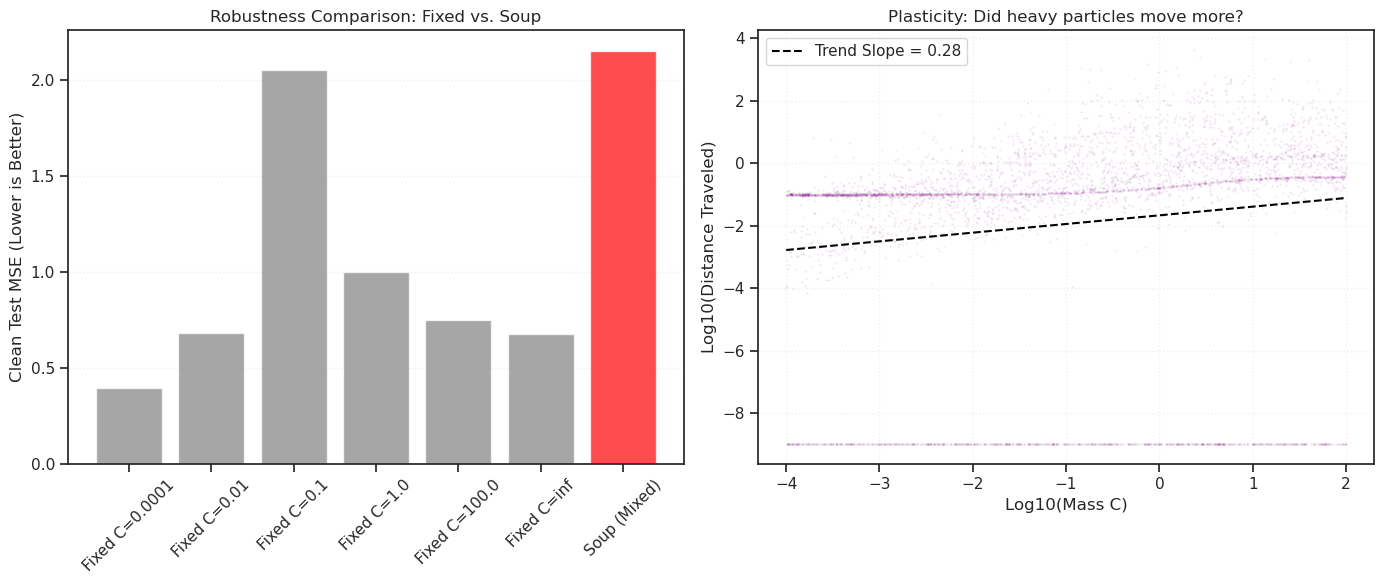

CPU times: user 4d 18h 49min 10s, sys: 3min 6s, total: 4d 18h 52min 17s
Wall time: 3h 39min 33s


In [6]:
%%time


run_particle_soup_experiment(
    n_samples=500,
    outlier_ratio=0.20,
    outlier_magnitude_max=8.0,
    n_steps=1000_000,
)